In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Caricare il dataset
df = pd.read_csv("indoor_data.csv")

# Rinominare le colonne per una migliore leggibilità
df.rename(columns={
    "field1": "MQ7_CO",
    "field2": "MQ135_AirQuality",
    "field3": "Temperature",
    "field4": "Humidity",
    "field5": "eCO2",
    "field6": "TVOC",
    "field7": "DustDensity"
}, inplace=True)

# Selezionare solo le colonne rilevanti per il training
df_clean = df[["MQ7_CO", "MQ135_AirQuality", "Temperature", "Humidity", "TVOC", "DustDensity", "eCO2"]].dropna()

# Definire feature e target
X = df_clean.drop(columns=["eCO2"])
y = df_clean["eCO2"]

# Suddivisione dei dati in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creazione del modello Random Forest Regressor e training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predizioni e valutazione del modello
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}, R2 Score: {r2}")

# -----------------------------
# GESTIONE AVANZATA DEGLI ADAPTER IOT PER eCO2
# -----------------------------

# Definizione delle soglie di qualità dell'aria
def classify_air_quality(eCO2):
    if eCO2 < 600:
        return "Buona"
    elif 600 <= eCO2 < 900:
        return "Moderata"
    else:
        return "Scarsa"

# Simulazione di dati in tempo reale
eCO2_live = 950  # Valore simulato da sensore
action = classify_air_quality(eCO2_live)
print(f"Situazione Attuale: {action}")

# Gestione avanzata degli attuatori basata sulle previsioni
def control_actuators(predicted_eco2):
    if predicted_eco2 < 700:
        return "Disattiva tutti gli attuatori"
    elif 700 <= predicted_eco2 < 900:
        return "Attiva Ventilazione"
    else:
        return "Attiva Ventilazione + Purificatore + Apertura Finestre + Notifica all'utente"

# Applicazione del controllo su dati di test
for features, predicted_eco2, actual_eco2 in zip(X_test.values, y_pred, y_test):
    air_quality = classify_air_quality(predicted_eco2)
    action = control_actuators(predicted_eco2)
    print(f"Predetto eCO2: {predicted_eco2:.2f}, Reale eCO2: {actual_eco2:.2f}, Qualità Aria: {air_quality}")

"""
Motivazione della Scelta delle Feature
Abbiamo distribuito le feature tra due sensori per garantire un monitoraggio ottimale:

- **Sensore 1 (Qualità dell'Aria Generale)**: Include **MQ135_AirQuality**, **Temperature**, **Humidity**, e **DustDensity**. Questi parametri misurano l'inquinamento generale e le condizioni ambientali.
- **Sensore 2 (Composti Chimici e Gas)**: Include **MQ7_CO**, **TVOC** e **eCO2**. Questo sensore si concentra sulle emissioni chimiche e sulla qualità dell'aria interna correlata alla CO2.

Questa suddivisione garantisce una copertura bilanciata:
- Il **Sensore 1** è utile per rilevare cambiamenti ambientali generali e particolato.
- Il **Sensore 2** fornisce dati più specifici sulle emissioni chimiche e sulla concentrazione di CO2.

Attuatori e Funzionamento
1. **Ventilazione Principale**: Attivata in caso di qualità Moderata o Scarsa.
2. **Purificatore d'Aria**: Attivato solo in caso di qualità Scarsa.
3. **Apertura Finestre**: Attivata quando la qualità dell'aria è Scarsa per migliorare il ricambio d’aria.
4. **Notifica all'Utente**: Inviata quando la qualità dell'aria è Scarsa per suggerire azioni aggiuntive.

Logica di Attivazione:
- **Qualità Buona** → Nessuna azione.
- **Qualità Moderata** → Attiva Ventilazione.
- **Qualità Scarsa** → Attiva Ventilazione + Purificatore + Apertura Finestre + Notifica all'utente.

Questa configurazione migliora il controllo della qualità dell’aria, garantendo un’azione mirata ed efficiente.
"""


Errore assoluto medio (MAE): 2.58
R-quadrato (R²): 1.00
CO: 195.00, TVOC: 44.00, Predetto eCO2: 692.55, Target eCO2: 692.00, Qualità Aria: MODERATA, Azione: Attiva Ventilazione
CO: 187.00, TVOC: 19.00, Predetto eCO2: 529.37, Target eCO2: 526.00, Qualità Aria: BASSA, Azione: Nessuna azione necessaria
CO: 215.00, TVOC: 41.00, Predetto eCO2: 672.93, Target eCO2: 675.00, Qualità Aria: MODERATA, Azione: Attiva Ventilazione
CO: 171.00, TVOC: 26.00, Predetto eCO2: 573.72, Target eCO2: 575.00, Qualità Aria: BASSA, Azione: Nessuna azione necessaria
CO: 163.00, TVOC: 27.00, Predetto eCO2: 579.12, Target eCO2: 581.00, Qualità Aria: BASSA, Azione: Nessuna azione necessaria
CO: 189.00, TVOC: 69.00, Predetto eCO2: 853.27, Target eCO2: 857.00, Qualità Aria: ALTA, Azione: Attiva Ventilazione + Purificatore
CO: 164.00, TVOC: 30.00, Predetto eCO2: 601.60, Target eCO2: 597.00, Qualità Aria: ALTA, Azione: Attiva Ventilazione + Purificatore
CO: 170.00, TVOC: 19.00, Predetto eCO2: 529.58, Target eCO2: 531.0

"\nScelta delle Feature per la Predizione di eCO₂\nAbbiamo selezionato TVOC (Total Volatile Organic Compounds) e MQ7_CO (Monossido di Carbonio) come feature principali per la predizione del livello di eCO₂ (equivalente di anidride carbonica). La scelta di queste variabili è basata su un’analisi statistica e sul loro impatto logico sulla qualità dell’aria.\n\nMotivazioni della Scelta\n1. TVOC (Total Volatile Organic Compounds)\n- Correlazione altissima con eCO₂ (≈ 0.9997), il che suggerisce che può essere considerato il miglior predittore.\n- I composti organici volatili sono rilasciati da materiali da costruzione, mobili, prodotti per la pulizia e attività umane, influenzando direttamente la qualità dell'aria interna e i livelli di eCO₂.\n- Sensori di eCO₂ spesso stimano i livelli di CO₂ sulla base delle concentrazioni di TVOC, quindi è una feature logicamente coerente per il nostro modello.\n2. MQ7_CO (Monossido di Carbonio)\n- Correlazione moderata con eCO₂ (≈ 0.3436), suggerendo che

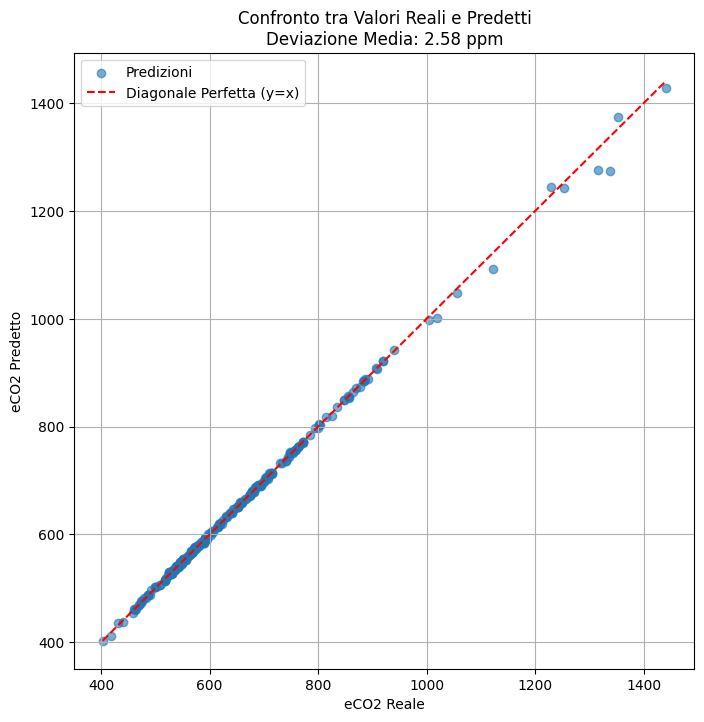

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calcoliamo la distanza assoluta tra i valori predetti e quelli reali
errors = np.abs(y_test - y_pred)
mean_error = np.mean(errors)

# Creazione del grafico di dispersione
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predizioni")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Diagonale Perfetta (y=x)")
plt.xlabel("eCO2 Reale")
plt.ylabel("eCO2 Predetto")
plt.title(f"Confronto tra Valori Reali e Predetti\nDeviazione Media: {mean_error:.2f} ppm")
plt.legend()
plt.grid(True)

# Mostra il grafico
plt.show()
